In [2]:
from util import *
from simulator import QuantumCircuitSimulator
from converter import CircuitConverter
from zne import ZNESimulator
from generator import QuantumGenerator
from extractor import QuantumGraphExtractor

Using CPU for statevector simulation
Running 20 iterations...
Simulations completed in 1.52 seconds

Ideal <Z^⊗n> Expectation (Iteration 1): -0.0010129701415167447
Noisy <Z^⊗n> Expectation (Iteration 1): -0.008056640625


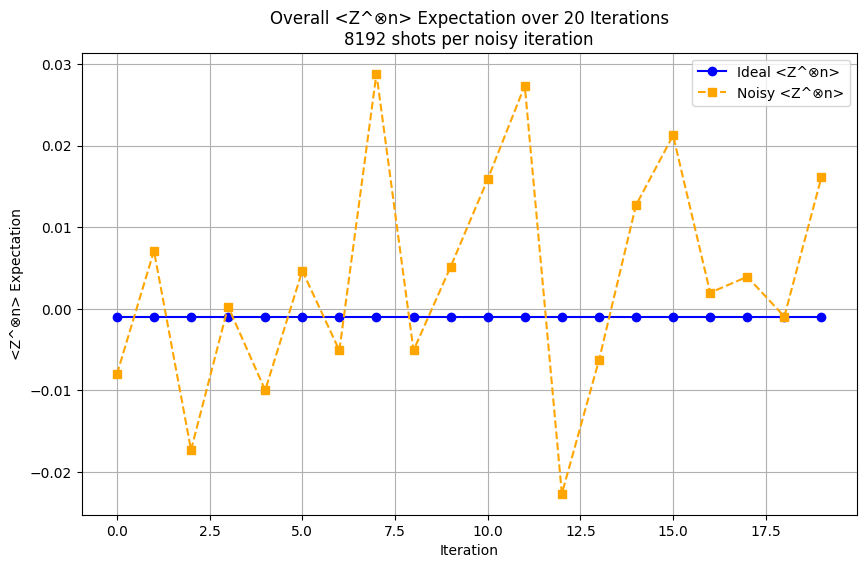

In [ ]:
# Generate a random circuit (without measurements)
n_qubits = 4
depth = 6
circuit = random_circuit(n_qubits, depth, measure=False, seed=42)

# Initialize the simulator with the given circuit and parameters.
simulator = QuantumCircuitSimulator(n_qubits, shots=8192, iterations=20)

# Run the simulation to obtain compiled circuits and overall expectation values.
ideal_circuit, noisy_circuit, ideal_expectation, noisy_expectation = simulator.run_simulation(circuit, verbose=True)

print("\nIdeal <Z^⊗n> Expectation (Iteration 1):", ideal_expectation[0])
print("Noisy <Z^⊗n> Expectation (Iteration 1):", noisy_expectation[0])

# Plot the overall expectation values over iterations.
simulator.plot_expectations(np.array(ideal_expectation), np.array(noisy_expectation))

In [4]:
# Generate a random circuit (without measurements)
n_qubits = 4
depth = 6
circuit = random_circuit(n_qubits, depth, measure=False, seed=42)

# Create a converter with settings for both graph and frequency conversions.
converter = CircuitConverter(
    max_gate_attributes=3,
    bin_min=-3.14,
    bin_max=3.14,
    bin_size=0.5,
    mode='bin'  # Try 'bin_gate' or 'bin_gate_attr' as alternatives.
)

# Convert to graph representation.
dataset_graph = converter.convert(circuit, conversion_type="graph")
print("Converted dataset (graph representation):")
print(dataset_graph)

# Convert to frequency representation.
dataset_freq = converter.convert(circuit, conversion_type="freq")
print("\nConverted dataset (frequency representation):")
print(dataset_freq)

# Convert to CNN representation.
dataset_cnn = converter.convert(circuit, conversion_type="cnn")
print("\nConverted dataset (cnn representation):")
print(dataset_cnn)

Converted dataset (graph representation):
{'nodes': [{'id': 0, 'vector': ['in', 0, 0, 0, 0, 0]}, {'id': 1, 'vector': ['h', 0, 0, 0, 0, 0]}, {'id': 2, 'vector': ['in', 0, 0, 0, 0, 0]}, {'id': 3, 'vector': ['in', 0, 0, 0, 0, 0]}, {'id': 4, 'vector': ['in', 0, 0, 0, 0, 0]}, {'id': 5, 'vector': ['ccz', 1, 0, 0, 0, 0]}, {'id': 6, 'vector': ['ccz', 0, 1, 0, 0, 0]}, {'id': 7, 'vector': ['ccz', 0, 1, 0, 0, 0]}, {'id': 8, 'vector': ['cp', 1, 0, 2.7860535790666945, 0, 0]}, {'id': 9, 'vector': ['cp', 0, 1, 2.7860535790666945, 0, 0]}, {'id': 10, 'vector': ['rz', 0, 0, 2.2275523539672073, 0, 0]}, {'id': 11, 'vector': ['ccz', 1, 0, 0, 0, 0]}, {'id': 12, 'vector': ['ccz', 0, 1, 0, 0, 0]}, {'id': 13, 'vector': ['ccz', 0, 1, 0, 0, 0]}, {'id': 14, 'vector': ['rccx', 1, 0, 0, 0, 0]}, {'id': 15, 'vector': ['rccx', 0, 1, 0, 0, 0]}, {'id': 16, 'vector': ['rccx', 0, 1, 0, 0, 0]}, {'id': 17, 'vector': ['rz', 0, 0, 2.327666981860357, 0, 0]}, {'id': 18, 'vector': ['ry', 0, 0, 2.746706513663991, 0, 0]}, {'id': 1

Simulation complete.

Ideal <Z^⊗n> Expectation: -7.306179901873631e-33
Noisy <Z^⊗n> Expectation: -0.036865234375
ZNE Mitigated Value (linear_zne): 0.0005696614583333111
ZNE Mitigated Value (richardson_zne): 0.03637695312500016


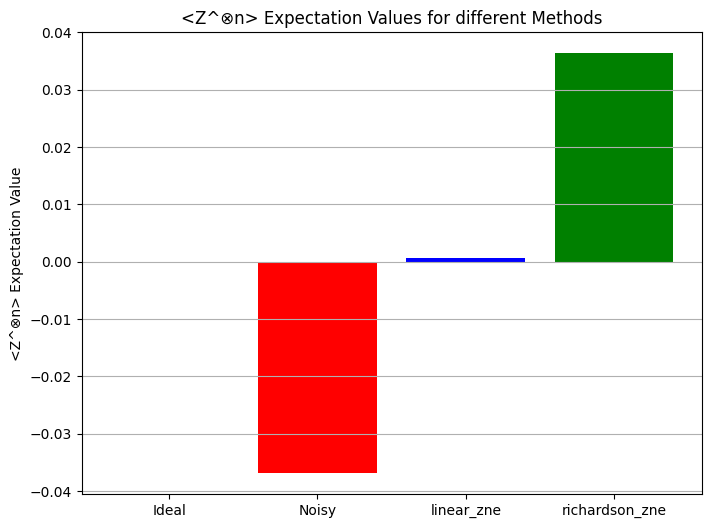

In [5]:
# Generate a random circuit (without measurements).
n_qubits = 4
depth = 6
shots = 8192
scale_factors = [1.0, 2.0, 3.0]
circuit = random_circuit(n_qubits, depth, measure=False, seed=42)

# Initialize the ZNESimulator.
zne_simulator = ZNESimulator(
    n_qubits=n_qubits,
    shots=shots,
    scale_factors=scale_factors
)

# Run the simulation (overall expectation calculations).
ideal_exp, noisy_exp, zne_results = zne_simulator.run_simulation(circuit, verbose=True)

print("\nIdeal <Z^⊗n> Expectation:", ideal_exp)
print("Noisy <Z^⊗n> Expectation:", noisy_exp)
for method, val in zne_results.items():
    print(f"ZNE Mitigated Value ({method}):", val)

# Plot the overall expectation values.
zne_simulator.plot_results(ideal_exp, noisy_exp, zne_results)

In [ ]:
# Create an instance of QuantumGenerator with desired parameters.
qgen = QuantumGenerator(
    n_qubits=10,
    depth=(2, 3, 2),         # Depth values: 4, 6, 8
    circuits_per_depth=1000,
    shots=8192,
    scale_factors=[1.0, 2.0, 3.0],
    observable_mode="fixed",   # Use random observables ("X", "Y", or "Z")
    fixed_pauli="ZZZZZZZZZZ",         # If fixed mode is used, provide a string e.g. "XYZZZ"
    optimization_level=0,
    transpile_backend=None,   # Uses default GenericBackendV2 if not provided.
    conversion_type=["graph", "cnn", "freq"],  # List of conversions, options: 'graph', 'freq', 'cnn' etc.
    save=True,
    filename="../../data/raw_data" # Additional info like nqbit, depth_params, circuits_per_depth are appended to file-name
)

# Generate the data and store it in a DataFrame.
df = qgen.generate_data(output_format='csv')
print("Generated Data:")
print(df)


Using CPU for statevector simulation
Generating circuits at depth: 2


Circuits at depth 2:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated Data:
{'graph':      Depth ObservablePattern  \
0        2        ZZZZZZZZZZ   
1        2        ZZZZZZZZZZ   
2        2        ZZZZZZZZZZ   
3        2        ZZZZZZZZZZ   
4        2        ZZZZZZZZZZ   
..     ...               ...   
995      2        ZZZZZZZZZZ   
996      2        ZZZZZZZZZZ   
997      2        ZZZZZZZZZZ   
998      2        ZZZZZZZZZZ   
999      2        ZZZZZZZZZZ   

                                          NoisyCircuit  \
0    ((Instruction(name='cx', num_qubits=2, num_clb...   
1    ((Instruction(name='rz', num_qubits=1, num_clb...   
2    ((Instruction(name='rz', num_qubits=1, num_clb...   
3    ((Instruction(name='cx', num_qubits=2, num_clb...   
4    ((Instruction(name='rz', num_qubits=1, num_clb...   
..                                                 ...   
995  ((Instruction(name='rz', num_qubits=1, num_clb...   
996  ((Instruction(name='rz', num_qubits=1, num_clb...   
997  ((Instruction(name='rz', num_qubits=1, num_clb...   
998  ((In

In [7]:
backend = qgen.transpile_backend  # Replace with actual backend if available.
extractor = QuantumGraphExtractor(filepath='../../data/raw_data_graph_10_(2, 3, 2)_1000.csv', n_qubits=4, backend=backend, data_type="graph")
extractor.process()
data_objects = extractor.get_data()
if data_objects is not None:
    print("Data processing complete.")
extractor.export_data("../../data/processed_data_graph_10_(2, 3, 2)_1000", output_format="csv")

Data processing complete.
Exported processed data to ../../data/processed_data_graph_10_(2, 3, 2)_1000.csv
